In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
from fnmatch import fnmatch
import pathlib as path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec

## Functions for reading aircraft data

In [3]:
def find_flight_fnames(dir_path: str) -> list[str]:
    """
    find_flight_fnames just searches a directory for all *.nc files and returns a list of them.

    :param dir_path: a path to the directory containing flight netcdf files

    :return: Returns a list of flight netcdf files.
    """
    flight_paths=[]
    flight_fnames = sorted([fname for fname in os.listdir(dir_path) if fnmatch(fname, "*.nc")])
    for i in range(len(flight_fnames)):
        flight_paths.append(dir_path + '/' + flight_fnames[i])
    
    return flight_paths

def open_nc(paths: str) -> xr.open_dataset:
    """
    open_flight_nc simply checks to see if the file at the provided path string exists and opens it.

    :param file_path: A path string to a flight data file, e.g. "./test/test_flight.nc"

    :return: Returns xr.open_dataset object.
    """

    nc_path = path.Path(paths)
    if not nc_path.is_file():
        raise FileNotFoundError('testing excptions')

    return xr.open_dataset(paths)

def read_flight_nc_1hz(nc: xr.open_dataset, read_vars: list[str]) -> pd.DataFrame:
    """
    read_flight_nc reads a set of variables into memory.

    NOTE: a low-rate, 1 Hz, flight data file is assumed

    :param nc: netCDF4._netCDF4.Dataset object opened by open_flight_nc.
    :param read_vars: An optional list of strings of variable names to be read into memory. A default
                      list, vars_to_read, is specified above. Passing in a similar list will read in those variables
                      instead.

    :return: Returns a pandas data frame.
    """

    data = [] # an empty list to accumulate Dataframes of each variable to be read in
    long_names = [nc[var].long_name if 'long_name' in nc[var].attrs else None for var in read_vars]
    for var in read_vars:
        try:
            if var == "Time":
                # time is provided every second, so need to calculate 25 Hz times efficiently
                # tunits = getattr(nc[var],'units')
                # df = xr.open_dataset(nc)
                time = np.array(nc.Time)
                data.append(pd.DataFrame({var: time}))
                # dt_list = sfm_to_datetime(time, tunits)
                # data.append(pd.DataFrame({'datetime': time}))
            else:
                output = nc[var][:]
                data.append(pd.DataFrame({var: output}))
        except Exception as e:
            print(f"Issue reading {var}: {e}")
            pass

    dataframe = pd.concat(data, axis=1, ignore_index=False)
    dataframe.attrs['long_names'] = long_names
    # concatenate the list of dataframes into a single dataframe and return it
    return dataframe
    
def read_flight_nc_25hz(nc: xr.open_dataset, read_vars) -> pd.DataFrame:
    """
    read_flight_nc reads a set of variables into memory.
    
    NOTE: a high-rate, usually 25 Hz, flight data file is assumed.
    
    :param nc: netCDF4._netCDF4.Dataset object opened by open_flight_nc.
    :param read_vars: An optional list of strings of variable names to be read into memory. A default
                      list, vars_to_read, is specified above. Passing in a similar list will read in those variables
                      instead.
    
    :return: Returns a pandas data frame.
    """
    data = []
    sub_seconds = np.arange(0,25,1)/25.
    for var in read_vars:
        try:
            if var == "Time":
                time = nc[var].values  # Get NumPy array from Xarray
                 # Convert sub_seconds into timedelta in nanoseconds
                sub_seconds_ns = (sub_seconds * 1e9).astype('timedelta64[ns]')
                # Expand time into 2D, add sub-second offsets
                time_25hz = time[:, None] + sub_seconds_ns
                output = time_25hz.ravel()  # Flatten to 1D
                data.append(pd.DataFrame({var: output}))
                # Get time units
                tunits = getattr(nc[var], "units", None)
                dt_list = output  # Directly use datetime values
                data.append(pd.DataFrame({"datetime": dt_list}))
            else:
                ndims = len(np.shape(nc[var][:]))
                if ndims == 2:
                    # 2-D, 25 Hz variables can just be raveled into 1-D time series
                    output = np.ravel(nc[var][:])
                    data.append(pd.DataFrame({var: output}))
                elif ndims == 1:
                    if var == 'GGALT':
                        ggalt = nc["GGALT"].values  # Extract array
                        ggalt = np.ravel(ggalt)  # Ensure it's 1D
                        data.append(pd.DataFrame({"GGALT": ggalt}))
                    else:
                        # 1-D variables in 25 Hz data files exist (e.g. GGALT is sampled at 20 Hz, but by default,
                        # this is filtered to 1Hz instead of fudged to 25 Hz). Do interpolation to 25 Hz so all time series
                        # have same length.
                        output_1d = nc[var][:]
                        output_2d = np.zeros((len(output_1d),hz))*float("NaN")
                        for i in range(len(output_1d)-1):
                            output_2d[i,:] = output_1d[i] + sub_seconds*(output_1d[i+1]-output_1d[i]) # divide by 1s omitted
                        output = np.ravel(output_2d)
                        data.append(pd.DataFrame({var: output}))
        except Exception as e:
            print(f"Issue reading {var}: {e}")
            pass
    # concatenate the list of dataframes into a single dataframe and return it
    dataframe = pd.concat(data, axis=1, ignore_index=False)
    return dataframe

def read_flight_nc(nc: xr.open_dataset, read_vars: list[str]) -> pd.DataFrame:
    """
    read_flight_nc simply figures out if the flight netcdf object is 1 hz or 25 hz and calls the appropriate reader.

    :param nc: A netcdf object for a flight netcdf file.
    :param read_vars: A list of variable names to be read in the netcdf object. Optional. Default is "vars_to_read" specified
                      above.

    :return: Returns Pandas DataFrame
    """
    dim_names = list(nc.dims)
    if 'sps25' in dim_names:
        df = read_flight_nc_25hz(nc, read_vars)
    else:
        df = read_flight_nc_1hz(nc, read_vars)
    return df

# Function to read in all the relevant variables from the NSF aircraft datasets
def read_vars(nc):

    var_list = nc.data_vars
    time = 'Time'
    # Spatial variables
    lat, lon, alt = 'GGLAT', 'GGLON', 'GGALT'
    
    # state variables
    temp = 'ATX'
    dwpt = 'DPXC'
    u = 'UIC' if 'UIC' in var_list else 'UIX'
    v = 'VIC' if 'VIC' in var_list else 'VIX'
    w = 'WIC' if 'WIC' in var_list else 'WIX'
    p = 'PSXC'
    ew = 'EWX'
    rh = 'RHUM'
    vars_to_read = [time, lat, lon, alt, temp, dwpt, u,  w, p, ew, rh]
    # Thermodynamic data
    if any('THETA' in var for var in var_list): 
        theta_vars = [var for var in var_list if 'THETA' in var]
        vars_to_read.extend(theta_vars)
    # Cloud microphysical
    if any('CONC' in var for var in var_list): # cloud concentrations
        conc_vars = [var for var in var_list if 'CONC' in var and 'D' in var and('_2' not in var and 'R_' not in var and 'CN' not in var)]
        # print(conc_vars)
        vars_to_read.extend(conc_vars)
    if any('PLW' in var for var in var_list): # Liquid/Ice water contents
        # v = [var for var in var_list if '2' not in var]
        wc_vars = [var for var in var_list if 'PLW' in var and '_2' not in var]
        vars_to_read.extend(wc_vars)
    # Aerosol data
    if any('UHSAS' in var for var in var_list) or any('CONCN' in var for var in var_list):
        aer_var = [var for var in var_list if ('UHSAS' in var or 'CONCU' in var or 'CONCN' in var) and ('AU' not in var and 'UD' not in var and 'CUH' not in var)]
        uhsas_cells = var_list['CUHSAS_LWII'].CellSizes
        vars_to_read.extend(aer_var)
    # print("Loaded variables:")
    # print(vars_to_read)
    return vars_to_read

In [134]:
dir = '/Users/patnaude/Documents/Data/SOCRATES/Aircraft_1Hz/'
flight_paths = find_flight_fnames(dir)
# flight_paths
# read_vars = ['Time','GGALT','LATC','LONC', # 4-D Position
#                 'UIC','VIC','WIC',            # winds
#                 'ATX','PSXC','EWX','RHUM',           # other state params
#                 ] 

nc = open_nc(flight_paths[2])
vars2read = read_vars(nc)
# vars_to_read = read_vars(nc)

df = read_flight_nc(nc,vars2read)
# df
# list = nc.data_vars

In [149]:
def assign_flight_type(df):
    """
    Assigns flight type ('level' or 'profile') to each row of the input DataFrame based on stable altitude blocks 
    and gaps between these blocks. The function uses rolling standard deviation of altitude to identify level legs
    and combines consecutive blocks of stable altitude with a specified time gap threshold. Additionally, it labels 
    flight segments as "level" for level legs and "profile" for the aircraft vertical profile.

    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame with at least the following columns:
        - 'Time' (timestamp)
        - 'GGALT' (altitude in meters)

    Returns:
    --------
    pandas.DataFrame
        The input DataFrame with a new column 'flight_type', where each row is assigned a flight type:
        - 'level' for stable altitude periods
        - 'profile' for gaps between stable altitude blocks

    Example:
    --------
    df = pd.read_csv('flight_data.csv')  # Assuming the CSV contains relevant columns
    df_with_flight_types = assign_flight_type(df)
    """
    # Define a time gap threshold to combine blocks (e.g., 120 seconds)
    time_gap_threshold = pd.Timedelta(seconds=120)
    
    # Compute rolling standard deviation of altitude to smooth noise
    df['rolling_std'] = df['GGALT'].rolling(window=10, center=True).std()
    
    # Identify where altitude remains stable within the threshold
    df['stable'] = df['rolling_std'] < 3  # You can adjust the threshold (meters)
    
    # Assign unique block IDs when stability changes
    df['block_id'] = (df['stable'] != df['stable'].shift()).cumsum()
    
    # Group by block_id and filter for long-duration stable blocks
    block_info = df[df['stable']].groupby('block_id').agg(
        start_time=('Time', 'first'),
        end_time=('Time', 'last'),
        lower_bound=('GGALT', 'min'),  # Minimum altitude (lower bound)
        upper_bound=('GGALT', 'max'),  # Maximum altitude (upper bound)
        duration=('Time', lambda x: x.max() - x.min())
    )
    
    # Filter out short-duration blocks
    valid_blocks = block_info[block_info['duration'] > pd.Timedelta(seconds=150)]
    
    # Sort the blocks by start time
    valid_blocks = valid_blocks.sort_values(by='start_time')
    
    # Define a time gap threshold to combine blocks (e.g., 120 seconds)
    time_gap_threshold = pd.Timedelta(seconds=180)
    
    # Combine consecutive blocks that are less than the threshold apart
    combined_blocks = []
    previous_block = valid_blocks.iloc[0]
    
    for idx, current_block in valid_blocks.iloc[1:].iterrows():
        # Check if the gap between the end time of the previous block and start time of the current block is below the threshold
        if current_block['start_time'] - previous_block['end_time'] <= time_gap_threshold:
            # Extend the previous block's end time to the current block's end time
            previous_block['end_time'] = current_block['end_time']
        else:
            # If the gap is too large, append the previous block and update to the current block
            combined_blocks.append(previous_block)
            previous_block = current_block
    
    # Add the last block after the loop
    combined_blocks.append(previous_block)
    
    # Convert combined blocks back to DataFrame
    combined_blocks_df = pd.DataFrame(combined_blocks)
    
    # --- Identify and Label "Profiles" between "Level" (Stable) sections ---
    
    # Create a new column 'flight_type' to categorize the blocks as "level" or "profile"
    combined_blocks_df['flight_type'] = 'level'  # By default, label as 'level'
    
    # Now identify the gaps between "level" blocks and label as "profile"
    profile_blocks = []
    for i in range(len(combined_blocks_df) - 1):
        end_time_current = combined_blocks_df.iloc[i]['end_time']
        start_time_next = combined_blocks_df.iloc[i + 1]['start_time']
        
        # If there's a gap between two 'level' blocks, label the gap as 'profile'
        if start_time_next - end_time_current > time_gap_threshold:
            # Assign 'profile' to the gap between two level blocks and calculate duration
            profile_duration = start_time_next - end_time_current  # Duration of the profile block
            
            profile_blocks.append({
                'start_time': end_time_current,
                'end_time': start_time_next,
                'flight_type': 'profile',
                'duration': profile_duration
            })
    
    # Convert 'profile_blocks' to DataFrame
    profile_blocks_df = pd.DataFrame(profile_blocks)
    
    # Append profile blocks to the original combined blocks DataFrame
    combined_blocks_with_profiles = pd.concat([combined_blocks_df, profile_blocks_df], ignore_index=True)
    
    # Sort again by time
    combined_blocks_with_profiles = combined_blocks_with_profiles.sort_values(by='start_time')
    
    # Check for "Profile" after the Last Level Block
    last_end_time = combined_blocks_with_profiles.iloc[-1]['end_time']
    last_time_in_data = df['Time'].max()
    
    if last_time_in_data - last_end_time > time_gap_threshold:
        # If the gap is greater than the threshold, consider it a "profile" block
        profile_block = pd.DataFrame([{
            'start_time': last_end_time,
            'end_time': last_time_in_data,
            'flight_type': 'profile',
        }])
    
        # Concatenate the new profile block to the existing DataFrame
        combined_blocks_with_profiles = pd.concat([combined_blocks_with_profiles, profile_block], ignore_index=True)
    # Check for "Profile" before the First Level Block
    first_start_time = combined_blocks_with_profiles.iloc[0]['start_time']
    first_time_in_data = df['Time'].min()
    
    if first_start_time - first_time_in_data > time_gap_threshold:
        profile_block_before_first = pd.DataFrame([{
            'start_time': first_time_in_data,
            'end_time': first_start_time,
            'flight_type': 'profile',
        }])
    
        combined_blocks_with_profiles = pd.concat([profile_block_before_first, combined_blocks_with_profiles], ignore_index=True)
    # List of columns to remove
    columns_to_remove = ['rolling_std','stable','block_id']
    # Drop the specified columns from df2
    df = df.drop(columns=columns_to_remove)
    
    # Add new column "flight_type" as either "level" or "profile"
    for _, row in combined_blocks_with_profiles.iterrows():
        flight_type = row['flight_type']
        # Find rows in df2 where the time is between start_time and end_time
        mask = (df['Time'] >= row['start_time']) & (df['Time'] <= row['end_time'])
        df.loc[mask, 'flight_type'] = flight_type
    # Assign the flight_type to the first few rows that fall before the first start_time in df1
    df.loc[df['Time'] < first_start_time, 'flight_type'] = df.iloc[0]['flight_type']

    #------------------------------
    #
    #----- Find cloud layers ------
    #
    #------------------------------
    
    # Ensure 'Time' is in datetime format
    df = df.copy()  # Avoid modifying original DataFrame
    df['Time'] = pd.to_datetime(df['Time'])
    
    # Create a mask where the conditions are met
    df['blocked'] = (df['PLWCD_RWIO'] > 0.001) & (df['CONCD_RWIO'] > 10)
    
    # Assign unique block IDs when blocked condition changes
    df['block_id'] = (df['blocked'] != df['blocked'].shift()).cumsum()
    
    # Group by block ID and filter only the blocked regions
    block_info = df[df['blocked']].groupby('block_id').agg(
        start_time=('Time', 'first'),
        end_time=('Time', 'last'),
        lower_bound=('GGALT', 'min'),  # Get the minimum altitude (lower bound)
        upper_bound=('GGALT', 'max'),  # Get the maximum altitude (upper bound)
    )
    
    # Calculate duration directly by subtracting start_time from end_time
    block_info['duration'] = block_info['end_time'] - block_info['start_time']
    
    # Filter out short-duration blocks
    min_vertical = 30  # Adjust as needed (100 meters in your case)
    valid_blocks = block_info[(block_info['upper_bound'] - block_info['lower_bound']) > min_vertical].reset_index(drop=True)
    
    # Define the altitude difference and time gap thresholds
    altitude_gap_threshold = 200  # Increased altitude gap threshold
    # time_gap_threshold = pd.Timedelta(minutes=20)  # Time gap threshold for merging
    
    # Sort the valid blocks by their start time to process them in sequence
    valid_blocks = valid_blocks.sort_values(by='lower_bound')
    
    # Initialize a list to store combined blocks
    combined_blocks = []
    previous_block = valid_blocks.iloc[0].to_dict()
    
    # Iterate through the blocks and merge those that are within the thresholds
    for idx, current_block in valid_blocks.iloc[1:].iterrows():
        # Calculate the altitude gap between the current block's lower bound and the previous block's upper bound
        altitude_gap = abs(current_block['lower_bound'] - previous_block['upper_bound'])
        
        # Calculate the time gap between the current block's start time and the previous block's end time
        time_gap = current_block['start_time'] - previous_block['end_time']
        # Check if the altitude gap is within the threshold or if the time gap is within the allowed range for smaller altitudes
        if altitude_gap <= altitude_gap_threshold :
            # If both criteria are met, merge the blocks
            previous_block['end_time'] = max(previous_block['end_time'], current_block['end_time'])  # Get the latest end time
            previous_block['start_time'] = min(previous_block['start_time'], current_block['start_time'])  # Get the earliest start time
            previous_block['upper_bound'] = max(previous_block['upper_bound'], current_block['upper_bound'])  # Update upper bound
            previous_block['lower_bound'] = min(previous_block['lower_bound'], current_block['lower_bound'])  # Update lower bound
            
            # Recalculate the duration for the merged block
            previous_block['duration'] = previous_block['end_time'] - previous_block['start_time']
        else:
            # If the blocks are far apart, save the previous block and move to the next one
            combined_blocks.append(previous_block)
            previous_block = current_block.to_dict()
    
    # Add the last block after the loop
    combined_blocks.append(previous_block)
    
    # Convert the merged blocks back into a DataFrame
    combined_blocks_df = pd.DataFrame(combined_blocks)
    
    # Second check for merging adjacent blocks in combined_blocks_df
    final_combined_blocks = []
    previous_block = combined_blocks_df.iloc[0].to_dict()
    
    # Apply additional check for merging based on both time and altitude gap
    for idx, current_block in combined_blocks_df.iloc[1:].iterrows():
        # Calculate the altitude gap and time gap
        altitude_gap = abs(current_block['lower_bound'] - previous_block['upper_bound'])
        time_gap = current_block['start_time'] - previous_block['end_time']
        
        # Check for overlap in the altitude ranges
        overlap_check = (current_block['lower_bound'] >= previous_block['lower_bound']) and (current_block['lower_bound'] <= previous_block['upper_bound'])
    
        # Check if both the altitude gap, time gap, or overlap condition is met
        if altitude_gap <= altitude_gap_threshold or overlap_check:
            # Merge the blocks
            previous_block['end_time'] = max(previous_block['end_time'], current_block['end_time'])
            previous_block['start_time'] = min(previous_block['start_time'], current_block['start_time'])
            previous_block['upper_bound'] = max(previous_block['upper_bound'], current_block['upper_bound'])
            previous_block['lower_bound'] = min(previous_block['lower_bound'], current_block['lower_bound'])
            
            # Recalculate the duration for the merged block
            previous_block['duration'] = previous_block['end_time'] - previous_block['start_time']
        else:
            # Save the previous block and move to the next one
            final_combined_blocks.append(previous_block)
            previous_block = current_block.to_dict()
    
    # Add the last block after the loop
    final_combined_blocks.append(previous_block)
    
    # Convert the final combined blocks back into a DataFrame
    final_cloud_blocks = pd.DataFrame(final_combined_blocks)

    # Add 'cloud_status' based on whether altitude and time fall within any blocked region (in the cloud or out of cloud)
    df['cloud_status'] = 'Out-of-cloud'  # Default label
    # Loop through each block and label altitudes as "In-cloud" if they fall within the block's range
    for _, block in final_cloud_blocks.iterrows():
        # Create a mask that checks both altitude and time conditions
        mask = (
            (df['GGALT'] >= block['lower_bound']) & (df['GGALT'] <= block['upper_bound']) &
            (df['Time'] >= block['start_time']) & (df['Time'] <= block['end_time'])
        )
        
        # Apply the 'In-cloud' label where the mask is True
        df.loc[mask, 'cloud_status'] = 'In-cloud'
    
    # List of columns to remove
    columns_to_remove = ['blocked','block_id']
    # Drop the specified columns from df2
    df = df.drop(columns=columns_to_remove)

    df['Location'] = 'Free'
    # Find the minimum in-cloud altitude
    min_ic_alt = np.min(final_cloud_blocks['lower_bound'])-5
    mask = df.GGALT < min_ic_alt
    # Define 
    df.loc[mask, 'Location'] = 'BL'

    # Update the Location column based on the GGALT and cloud status
    df.loc[df['GGALT'] < min_ic_alt, 'Location'] = 'BL'

    # --- Add Location to final_cloud_blocks DataFrame ---
    # Add 'Location' based on the minimum in-cloud altitude
    final_cloud_blocks['Location'] = final_cloud_blocks['lower_bound'].apply(
        lambda x: 'BL' if x < min_ic_alt else 'Free'
    )
        # Add 'Location' based on the minimum in-cloud altitude
    combined_blocks_with_profiles['Location'] = combined_blocks_with_profiles['lower_bound'].apply(
        lambda x: 'BL' if x < min_ic_alt else 'Free'
    )

    # Sort the dataframe by Time for continuous time grouping
    df = df.sort_values(by='Time')
    # Remove rows where 'flight_type' is NaN
    df = df.dropna(subset=['flight_type'])
    # Create a new column 'block_id' to group continuous time periods based on flight_type, cloud_status, and Location
    df['block_id'] = (df['flight_type'] != df['flight_type'].shift()) | \
                      (df['cloud_status'] != df['cloud_status'].shift()) | \
                      (df['Location'] != df['Location'].shift())
    df['block_id'] = df['block_id'].cumsum()

    return df, combined_blocks_with_profiles, final_cloud_blocks

# mod_df, blocks = assign_flight_type(df)

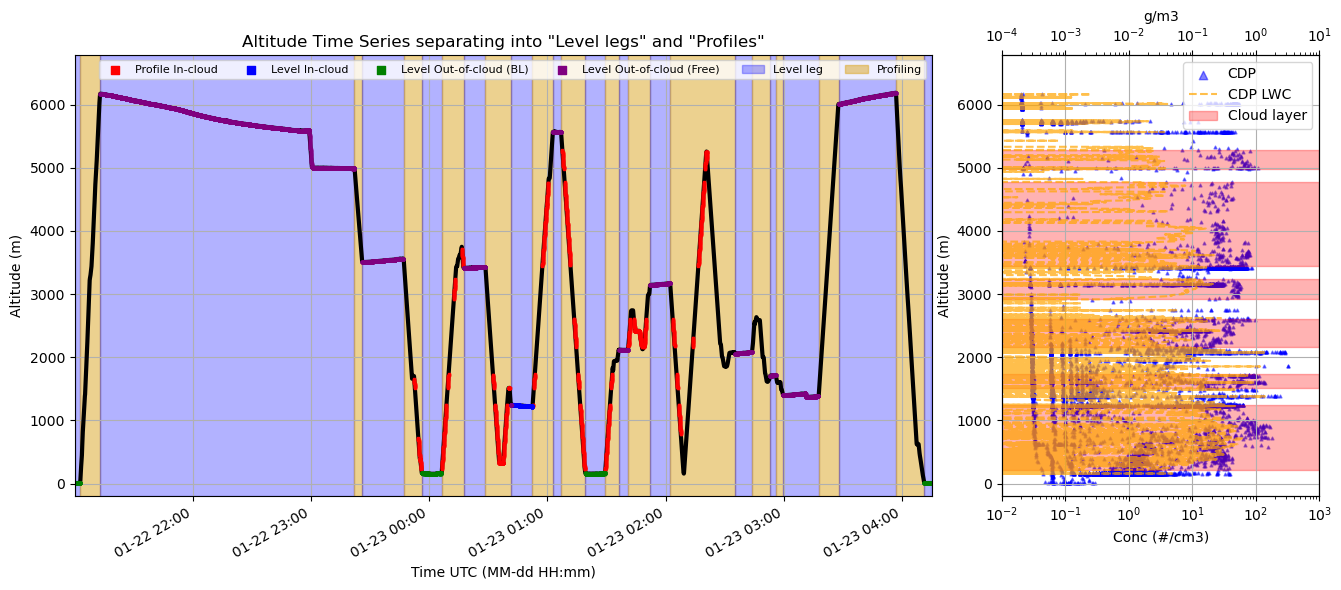

In [164]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Assuming the four DataFrames are already created
# profile_in_cloud, level_in_cloud, level_out_cloud_bl, level_out_cloud_fr
df, blocks, incloud = assign_flight_type(df)
# Creating the four DataFrames based on flight_type, cloud status, and Location
profile_in_cloud = df[(df['flight_type'] == 'profile') & (df['cloud_status'] == 'In-cloud')]
level_in_cloud = df[(df['flight_type'] == 'level') & (df['cloud_status'] == 'In-cloud') & (df['Location'] != 'BL')]
level_out_cloud_bl = df[(df['flight_type'] == 'level') & (df['cloud_status'] != 'In-cloud') & (df['Location'] == 'BL')]
level_out_cloud_fr = df[(df['flight_type'] == 'level') & (df['cloud_status'] != 'In-cloud') & (df['Location'] == 'Free')]
# Create figure and GridSpec layout
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.7, 1])  # First subplot is 3x the width of the second

# First subplot (larger)
ax1 = fig.add_subplot(gs[0])  # Assigning first subplot

# Plot flight altitude for each DataFrame in different colors
ax1.plot(df['Time'], df['GGALT'], color='k', linewidth=3)

# Plot In-cloud, Level In-cloud, and other data
ax1.scatter(profile_in_cloud['Time'], profile_in_cloud['GGALT'], color='red', label='Profile In-cloud', marker='s', s=1, zorder=2)
ax1.scatter(level_in_cloud['Time'], level_in_cloud['GGALT'], color='blue', label='Level In-cloud', marker='s', s=1, zorder=2)
ax1.scatter(level_out_cloud_bl['Time'], level_out_cloud_bl['GGALT'], color='green', label='Level Out-of-cloud (BL)', marker='s', s=1, zorder=2)
ax1.scatter(level_out_cloud_fr['Time'], level_out_cloud_fr['GGALT'], color='purple', label='Level Out-of-cloud (Free)', marker='s', s=1, zorder=2)

# Set x-axis limits
start_limit = df['Time'].min()
end_limit = df['Time'].max()
ax1.set_xlim([start_limit, end_limit])

# Format x-axis to show only hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))  # Adjust format as needed
fig.autofmt_xdate()

# Shade blocks according to their type (level or profile)
for _, row in blocks.iterrows():
    start_time, end_time, flight_type = row['start_time'], row['end_time'], row['flight_type']
    if flight_type == 'level':
        ax1.axvspan(start_time, end_time, color='blue', alpha=0.3, label="Level leg" if 'Level leg' not in ax1.get_legend_handles_labels()[1] else None)
    elif flight_type == 'profile':
        ax1.axvspan(start_time, end_time, color='goldenrod', alpha=0.5, label="Profiling" if 'Profiling' not in ax1.get_legend_handles_labels()[1] else None)

# Labels and title
ax1.set_xlabel('Time UTC (MM-dd HH:mm)')
ax1.set_ylabel('Altitude (m)')
ax1.set_title('Altitude Time Series separating into "Level legs" and "Profiles"')
ax1.set_ylim(-200, np.max(df['GGALT'] + 600))
ax1.legend(loc='upper right', ncol=6, markerscale=6,fontsize=8)
ax1.grid(True)

# Second subplot (smaller)
ax2 = fig.add_subplot(gs[1])  # Assigning second subplot

# Scatter plot for concentration and altitude
ax2.scatter(df.CONCD_RWIO, df.GGALT, color='b', label='CDP', alpha=0.5, marker='^', s=4)

# Log scale for x-axis
ax2.set_xscale('log')
ax2.set_xlabel('Conc (#/cm3)')
ax2.set_ylabel('Altitude (m)')
ax2.grid(True)
ax2.set_xlim(.01, 1000)

# Add second x-axis on top
ax2_top = ax2.twiny()
ax2_top.plot(df.PLWCD_RWIO, df.GGALT, color='orange', alpha=.7, linestyle='--', label='CDP LWC')
ax2_top.set_xlabel('g/m3')
ax2_top.set_xscale('log')
ax2_top.set_xlim(0.0001, 10)
ax2.set_ylim(-200, np.max(df['GGALT'] + 600))

# Shade blocked altitude regions in ax2
for i, row in incloud.iterrows():
    ax2.fill_betweenx(
        y=[row['lower_bound'], row['upper_bound']],  # Altitude range for shading
        x1=0.01,  # Left bound (min x-value)
        x2=1000,  # Right bound (max x-value)
        color='red', alpha=0.3, label="Cloud layer" if 'Cloud layer' not in ax2.get_legend_handles_labels()[1] else None
    )

# Merge legends from both axes
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_top.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')  # Merge legends from both axes

# Reorder the legends if needed
all_lines = lines + lines2
all_labels = labels + labels2
if len(all_labels) >= 3:
    new_order = [0, 2, 1]  # Modify based on the desired order
    all_lines = [all_lines[i] for i in new_order]
    all_labels = [all_labels[i] for i in new_order]

# Apply reordered legend
ax2.legend(all_lines, all_labels, loc='upper right', markerscale=3)

# Adjust layout to prevent overlap
plt.tight_layout()
fig.subplots_adjust(wspace=0.12)  # Increase spacing between subplots

# Save the figure
# plt.savefig("SOCRATES_Altitude_Flight_Cloud_type.png", dpi=300, bbox_inches='tight')  # Save as PNG with high resolution


* #### Need to think about how to manually identify the cloud layers and classify the "level" legs and in-cloud, boundary layer, clear-air FT
* #### Use the plot above to assist
* #### Attempt to shade the horizontal cloud layers on subplot 2
* #### CDP concentrations at lower altitude < 10 cm-3 are likely sea salt

In [141]:
df, blocks, incloud = assign_flight_type(df)

# Convert start_time and end_time columns to datetime format for comparison
blocks[['start_time', 'end_time']] = blocks[['start_time', 'end_time']].apply(pd.to_datetime)

# Function to check if a given time block falls within an in-cloud period, considering 'Location' column
def is_in_cloud(block_start, block_end, block_location, incloud_df):
    for _, row in incloud_df.iterrows():
        cloud_start, cloud_end, cloud_location = row['start_time'], row['end_time'], row['Location']
        if block_start <= cloud_end and block_end >= cloud_start:
            # If the block's location is 'BL' or 'Free' and falls within the cloud, classify accordingly
            if block_location != 'BL':  # Only consider non-'BL' and non-'Free' as 'in-cloud'
                return True
    return False

# Split blocks into profile and level first and create copies
profile_blocks = blocks[blocks['flight_type'] == 'profile'].copy()
level_blocks = blocks[blocks['flight_type'] == 'level'].copy()

# Apply the function to classify each row in the profile and level blocks, considering Location
profile_blocks['in_cloud'] = profile_blocks.apply(lambda row: is_in_cloud(row['start_time'], row['end_time'], row['Location'], incloud), axis=1)
level_blocks['in_cloud'] = level_blocks.apply(lambda row: is_in_cloud(row['start_time'], row['end_time'], row['Location'], incloud), axis=1)

# Now combine both profile and level blocks back into a single DataFrame
blocks = pd.concat([profile_blocks, level_blocks])

# Creating the four DataFrames based on flight_type, cloud status, and Location
profile_in_cloud = blocks[(blocks['flight_type'] == 'profile') & (blocks['in_cloud'])]
level_in_cloud = blocks[(blocks['flight_type'] == 'level') & (blocks['in_cloud']) & (blocks['Location'] != 'BL')]
level_out_cloud_bl = blocks[(blocks['flight_type'] == 'level') & (~blocks['in_cloud']) & (blocks['Location'] == 'BL')]
level_out_cloud_fr = blocks[(blocks['flight_type'] == 'level') & (~blocks['in_cloud']) & (blocks['Location'] == 'Free')]

# # Print results
# print("Profile In-cloud:\n", profile_in_cloud)
# print("Level In-Cloud:\n", level_in_cloud)
# print("Level Out-of-Cloud FT:\n", level_out_cloud_fr)
# print("Level Out-of-Cloud BL:\n", level_out_cloud_bl)



ValueError: too many values to unpack (expected 3)

## Testing 

In [35]:
import pandas as pd

# def assign_blocked_altitudes(df):
#     """
#     Identifies continuous blocks of altitudes where PLWCD_RWIO < 0.001 and CONCD_RWIO < 10.

#     Parameters:
#     -----------
#     df : pandas.DataFrame
#         - 'Time' (timestamp)
#         - 'GGALT' (altitude in meters)
#         - 'PLWCD_RWIO' (Liquid Water Content)
#         - 'CONCD_RWIO' (Concentration of Particles)

#     Returns:
#     --------
#     pandas.DataFrame
#         - A DataFrame with start_time, end_time, mean_altitude, and duration of blocked regions.

import pandas as pd

# Ensure 'Time' is in datetime format
df = df.copy()  # Avoid modifying original DataFrame
df['Time'] = pd.to_datetime(df['Time'])

# Create a mask where the conditions are met
df['blocked'] = (df['PLWCD_RWIO'] > 0.001) & (df['CONCD_RWIO'] > 10)

# Assign unique block IDs when blocked condition changes
df['block_id'] = (df['blocked'] != df['blocked'].shift()).cumsum()

# Group by block ID and filter only the blocked regions
block_info = df[df['blocked']].groupby('block_id').agg(
    start_time=('Time', 'first'),
    end_time=('Time', 'last'),
    lower_bound=('GGALT', 'min'),  # Get the minimum altitude (lower bound)
    upper_bound=('GGALT', 'max'),  # Get the maximum altitude (upper bound)
)

# Calculate duration directly by subtracting start_time from end_time
block_info['duration'] = block_info['end_time'] - block_info['start_time']

# Filter out short-duration blocks
min_vertical = 100  # Adjust as needed (100 meters in your case)
valid_blocks = block_info[(block_info['upper_bound'] - block_info['lower_bound']) > min_vertical].reset_index(drop=True)

# Define the altitude difference and time gap thresholds
altitude_gap_threshold = 200  # Increased altitude gap threshold
# time_gap_threshold = pd.Timedelta(minutes=20)  # Time gap threshold for merging

# Sort the valid blocks by their start time to process them in sequence
valid_blocks = valid_blocks.sort_values(by='lower_bound')

# Initialize a list to store combined blocks
combined_blocks = []
previous_block = valid_blocks.iloc[0].to_dict()

# Iterate through the blocks and merge those that are within the thresholds
for idx, current_block in valid_blocks.iloc[1:].iterrows():
    # Calculate the altitude gap between the current block's lower bound and the previous block's upper bound
    altitude_gap = abs(current_block['lower_bound'] - previous_block['upper_bound'])
    
    # Calculate the time gap between the current block's start time and the previous block's end time
    time_gap = current_block['start_time'] - previous_block['end_time']
    # Check if the altitude gap is within the threshold or if the time gap is within the allowed range for smaller altitudes
    if altitude_gap <= altitude_gap_threshold :
        # If both criteria are met, merge the blocks
        previous_block['end_time'] = max(previous_block['end_time'], current_block['end_time'])  # Get the latest end time
        previous_block['start_time'] = min(previous_block['start_time'], current_block['start_time'])  # Get the earliest start time
        previous_block['upper_bound'] = max(previous_block['upper_bound'], current_block['upper_bound'])  # Update upper bound
        previous_block['lower_bound'] = min(previous_block['lower_bound'], current_block['lower_bound'])  # Update lower bound
        
        # Recalculate the duration for the merged block
        previous_block['duration'] = previous_block['end_time'] - previous_block['start_time']
    else:
        # If the blocks are far apart, save the previous block and move to the next one
        combined_blocks.append(previous_block)
        previous_block = current_block.to_dict()

# Add the last block after the loop
combined_blocks.append(previous_block)

# Convert the merged blocks back into a DataFrame
combined_blocks_df = pd.DataFrame(combined_blocks)

# Second check for merging adjacent blocks in combined_blocks_df
final_combined_blocks = []
previous_block = combined_blocks_df.iloc[0].to_dict()

# Apply additional check for merging based on both time and altitude gap
for idx, current_block in combined_blocks_df.iloc[1:].iterrows():
    # Calculate the altitude gap and time gap
    altitude_gap = abs(current_block['lower_bound'] - previous_block['upper_bound'])
    time_gap = current_block['start_time'] - previous_block['end_time']
    
    # Check for overlap in the altitude ranges
    overlap_check = (current_block['lower_bound'] >= previous_block['lower_bound']) and (current_block['lower_bound'] <= previous_block['upper_bound'])

    # Check if both the altitude gap, time gap, or overlap condition is met
    if altitude_gap <= altitude_gap_threshold or overlap_check:
        # Merge the blocks
        previous_block['end_time'] = max(previous_block['end_time'], current_block['end_time'])
        previous_block['start_time'] = min(previous_block['start_time'], current_block['start_time'])
        previous_block['upper_bound'] = max(previous_block['upper_bound'], current_block['upper_bound'])
        previous_block['lower_bound'] = min(previous_block['lower_bound'], current_block['lower_bound'])
        
        # Recalculate the duration for the merged block
        previous_block['duration'] = previous_block['end_time'] - previous_block['start_time']
    else:
        # Save the previous block and move to the next one
        final_combined_blocks.append(previous_block)
        previous_block = current_block.to_dict()

# Add the last block after the loop
final_combined_blocks.append(previous_block)

# Convert the final combined blocks back into a DataFrame
final_combined_blocks_df = pd.DataFrame(final_combined_blocks)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

df = assign_flight_type(df)
# Create figure and GridSpec layout
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.7, 1])  # First subplot is 3x the width of the second

# First subplot (larger)
ax1 = fig.add_subplot(gs[0])  # Assigning first subplot
# Iterate over the rows and plot points with the corresponding color
# Create two subsets: one for 'In-cloud' and another for 'Out-of-cloud'
in_cloud_df = df[df['cloud_status'] == 'In-cloud']
out_of_cloud_df = df[df['cloud_status'] == 'Out-of-cloud']
bl_df = df[df.Location == 'BL']

# print(in_cloud_df)
# Plot the 'In-cloud' data with a red line
ax1.plot(df['Time'], df['GGALT'], color='k',linewidth=3,label='Flight Altitude')
ax1.scatter(in_cloud_df['Time'], in_cloud_df['GGALT'], color='red', label='In-cloud',marker='s',s=1,zorder=2)
ax1.scatter(bl_df.Time, bl_df.GGALT,color='green',label='Boundary Layer',marker='s',s=1,zorder=2)
# Set x-axis limits
# start_limit = pd.to_datetime('2018-01-19 03:30:00')
# end_limit = pd.to_datetime('2018-01-19 06:30:00')
start_limit = df['Time'].min()
end_limit = df['Time'].max()
ax1.set_xlim([start_limit, end_limit])
# Format x-axis to show only hours, minutes, and seconds
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))  # Adjust format as needed
# Improve date readability by auto-rotating the labels
fig.autofmt_xdate()
# Shade blocks according to their type (level or profile)
for _, row in blocks.iterrows():
    start_time, end_time, flight_type = row['start_time'], row['end_time'], row['flight_type']
    
    if flight_type == 'level':
        ax1.axvspan(start_time, end_time, color='blue', alpha=0.3, label="Level leg" if 'Level leg' not in ax1.get_legend_handles_labels()[1] else None)
    elif flight_type == 'profile':
        ax1.axvspan(start_time, end_time, color='goldenrod', alpha=0.5, label="Profiling" if 'Profiling' not in ax1.get_legend_handles_labels()[1] else None)

# Labels and title
ax1.set_xlabel('Time UTC (MM-dd HH:mm)')
ax1.set_ylabel('Altitude (m)')
ax1.set_title('Altitude Time Series separating into "Level legs" and "Profiles"')
ax1.set_ylim(-200, np.max(df['GGALT']+600))
ax1.legend(loc='upper right', ncol=5,markerscale=6)
# Adjust layout to prevent overlap
plt.tight_layout()
ax1.grid(True)

# Second subplot (smaller)
ax2 = fig.add_subplot(gs[1])  # Assigning second subplot
ax2.scatter(df.CONCD_RWIO, df.GGALT,color='b',label='CDP',alpha=0.5,marker='^',s=4)
# ax2.scatter(df.CONCU_LWII, df.GGALT,color='k',label='UHSAS')
ax2.set_xscale('log')
ax2.set_xlabel('Conc (#/cm3)')
ax2.set_ylabel('Altitude (m)')
# ax2.set_title('Scatter Plot')
# ax2.legend(loc = 'upper left',markerscale=3)
ax2.grid(True)
ax2.set_xlim(.01, 1000)


# Add second x-axis on top
ax2_top = ax2.twiny()  
ax2_top.plot(df.PLWCD_RWIO, df.GGALT, color='orange',alpha=.7, linestyle='--', label='CDP LWC')  
ax2_top.set_xlabel('g/m3')
ax2_top.set_xscale('log')
ax2_top.set_xlim(0.0001, 10)
ax2.set_ylim(-200, np.max(df['GGALT']+600))
# Shade blocked altitude regions in ax2
for i, row in incloud.iterrows():
    ax2.fill_betweenx(
        y=[row['lower_bound'], row['upper_bound']],  # Altitude range for shading
        x1=0.01,  # Left bound (min x-value)
        x2=1000,  # Right bound (max x-value)
        color='red', alpha=0.3, label="Cloud layer" if 'Cloud layer' not in ax2.get_legend_handles_labels()[1] else None
    )

# Merge legends from both axes
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_top.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')# Merge legends from both axes
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_top.get_legend_handles_labels()

# Combine both legend entries
all_lines = lines + lines2
all_labels = labels + labels2

# Define the new order (Modify based on actual labels)
# Example: Moving the second item to the last position
if len(all_labels) >= 3:
    new_order = [0, 2, 1]  # First stays first, third moves second, second moves third
    all_lines = [all_lines[i] for i in new_order]
    all_labels = [all_labels[i] for i in new_order]

# Apply reordered legend
ax2.legend(all_lines, all_labels, loc='upper right',markerscale=3)

# Adjust layout to prevent overlap
plt.tight_layout()
fig.subplots_adjust(wspace=0.12)  # Increase spacing between subplots

# Show the plot
# plt.show()
# Save the figure
# plt.savefig("SOCRATES_Altitude_Flight_type.png", dpi=300, bbox_inches='tight')  # Save as PNG with high resolution

In [151]:
np.max(df['block_id'])

np.int64(92)

In [152]:
df

,Time,GGLAT,GGLON,GGALT,ATX,DPXC,UIC,WIC,PSXC,EWX,...,CONCU100_CVIU,CONCU100_LWII,CONCU500_CVIU,CONCU500_LWII,CONCU_CVIU,CONCU_LWII,flight_type,cloud_status,Location,block_id
5,2018-01-22 21:00:05,-42.837757,147.513123,6.99481,17.048063,7.026299,0.0,0.0,1007.446228,10.039652,...,0.0,129.752075,0.0,0.000000,0.000000,226.102615,level,Out-of-cloud,BL,1
6,2018-01-22 21:00:06,-42.837730,147.513184,6.99557,17.061438,7.388413,0.0,0.0,1007.418335,10.292558,...,0.0,152.526337,0.0,1.281734,0.000000,269.164124,level,Out-of-cloud,BL,1
7,2018-01-22 21:00:07,-42.837708,147.513260,7.00364,17.020479,7.137760,0.0,0.0,1007.444824,10.117498,...,0.0,148.687317,0.0,1.281787,0.000000,284.556763,level,Out-of-cloud,BL,1
8,2018-01-22 21:00:08,-42.837688,147.513321,7.02061,16.988358,7.147235,0.0,0.0,1007.446350,10.124115,...,0.0,170.678360,0.0,2.566592,4.601091,320.823975,level,Out-of-cloud,BL,1
9,2018-01-22 21:00:09,-42.837677,147.513397,7.04177,16.970303,7.229937,0.0,0.0,1007.431213,10.181875,...,0.0,146.184753,0.0,2.564645,1.530672,268.005371,level,Out-of-cloud,BL,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26092,2018-01-23 04:14:52,-42.839012,147.509598,7.23916,25.591742,5.784532,0.0,0.0,1006.295776,9.216496,...,NaN,NaN,NaN,NaN,NaN,NaN,level,Out-of-cloud,BL,92
26093,2018-01-23 04:14:53,-42.838970,147.509537,7.21001,25.659328,5.741534,0.0,0.0,1006.337769,9.189086,...,NaN,NaN,NaN,NaN,NaN,NaN,level,Out-of-cloud,BL,92
26094,2018-01-23 04:14:54,-42.838932,147.509491,7.18344,25.572721,4.965477,0.0,0.0,1006.305176,8.705298,...,NaN,NaN,NaN,NaN,NaN,NaN,level,Out-of-cloud,BL,92
26095,2018-01-23 04:14:55,-42.838894,147.509430,7.15979,25.490530,5.171612,0.0,0.0,1006.312256,8.832090,...,NaN,NaN,NaN,NaN,NaN,NaN,level,Out-of-cloud,BL,92
